# 01. Carga inicial del dataset

Este notebook documenta la carga de los cuatro ficheros CSV que componen
el dataset [Takeaway Food Orders](https://www.kaggle.com/datasets/henslersoftware/19560-indian-takeaway-orders),
seleccionado como caso de validación del sistema (ver apartado 4.3 del TFG).

El dataset contiene los pedidos realizados a dos restaurantes de comida
india para llevar ubicados en Londres entre septiembre de 2015 y agosto
de 2019, junto con el catálogo de productos y precios de cada uno.

El objetivo de esta primera fase es:

1. Cargar los cuatro ficheros originales sin modificarlos.
2. Inspeccionar su estructura y tipos de datos.
3. Unificar los pedidos de ambos restaurantes en una única serie temporal.
4. Dejar el dataset preparado para el enriquecimiento con variables
   contextuales (meteorología y festivos) que se realizará en el
   notebook siguiente.

## 1. Configuración de rutas

Se definen las rutas a los cuatro ficheros del dataset y se comprueba que
están disponibles antes de continuar. Se utiliza `pathlib.Path` para
garantizar la compatibilidad entre sistemas operativos (RNF09).

In [14]:
import pandas as pd
from pathlib import Path

# Rutas base del proyecto
DATA_RAW = Path("../data/raw")

# Ficheros del dataset
FICHEROS = {
    "pedidos_r1": DATA_RAW / "restaurant-1-orders.csv",
    "pedidos_r2": DATA_RAW / "restaurant-2-orders.csv",
    "precios_r1": DATA_RAW / "restaurant-1-products-price.csv",
    "precios_r2": DATA_RAW / "restaurant-2-products-price.csv",
}

# Verificamos que los cuatro ficheros existen antes de continuar
for nombre, ruta in FICHEROS.items():
    assert ruta.exists(), f"No se encuentra {nombre} en {ruta}"
    print(f"✓ {nombre}: {ruta.name} ({ruta.stat().st_size / 1024:.1f} KB)")

✓ pedidos_r1: restaurant-1-orders.csv (3370.4 KB)
✓ pedidos_r2: restaurant-2-orders.csv (5339.4 KB)
✓ precios_r1: restaurant-1-products-price.csv (5.3 KB)
✓ precios_r2: restaurant-2-products-price.csv (6.5 KB)


## 2. Inspección inicial

Antes de realizar cualquier transformación se inspeccionan los cuatro
ficheros originales para confirmar su estructura, el nombre
de las columnas y los tipos de datos deducidos por pandas. Esta primera
lectura permite detectar posibles inconsistencias entre los CSV de los
dos restaurantes y organizar los pasos de preprocesado.

In [15]:
# Cargamos los cuatro ficheros y echamos un vistazo a su estructura
dfs = {nombre: pd.read_csv(ruta) for nombre, ruta in FICHEROS.items()}

for nombre, df in dfs.items():
    print(f"\n{'=' * 60}")
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"{'=' * 60}")
    print(f"\nColumnas: {list(df.columns)}")
    print(f"\nPrimeras 3 filas:")
    print(df.head(3))
    print(f"\nTipos de datos:")
    print(df.dtypes)


pedidos_r1: 74,818 filas × 6 columnas

Columnas: ['Order Number', 'Order Date', 'Item Name', 'Quantity', 'Product Price', 'Total products']

Primeras 3 filas:
   Order Number        Order Date         Item Name  Quantity  Product Price  \
0         16118  03/08/2019 20:25     Plain Papadum         2           0.80   
1         16118  03/08/2019 20:25  King Prawn Balti         1          12.95   
2         16118  03/08/2019 20:25       Garlic Naan         1           2.95   

   Total products  
0               6  
1               6  
2               6  

Tipos de datos:
Order Number        int64
Order Date            str
Item Name             str
Quantity            int64
Product Price     float64
Total products      int64
dtype: object

pedidos_r2: 119,183 filas × 6 columnas

Columnas: ['Order ID', 'Order Date', 'Item Name', 'Quantity', 'Product Price', 'Total products']

Primeras 3 filas:
   Order ID        Order Date             Item Name  Quantity  Product Price  \
0     25583  03

## 3. Unificación de los pedidos de ambos restaurantes

Los ficheros de pedidos de los dos restaurantes presentan la misma
estructura pero difieren en el nombre de la columna identificadora
(`Order Number` en el restaurante 1 y `Order ID` en el restaurante 2).
Además, los ids son numéricos e independientes entre
restaurantes, por lo que pueden colisionar al fusionarlos.

Para construir un único DataFrame de pedidos se realizan tres
operaciones: 
1. Se renombran las columnas para unificar los nombres
2. Se añade un identificador de restaurante que permite distinguir el origen
de cada pedido
3. Se concatenan ambos conjuntos en una única estructura.

Los ficheros de precios (`precios_r1` y `precios_r2`) no se incorporan
al DataFrame principal, ya que el sistema predice el número de pedidos
(no su facturación) y el precio unitario no interviene en esa predicción.

In [16]:
# 1. Renombramos columnas del restaurante 2 para unificar esquemas
dfs["pedidos_r2"] = dfs["pedidos_r2"].rename(columns={"Order ID": "Order Number"})

# 2. Añadimos un identificador de restaurante a cada conjunto
dfs["pedidos_r1"]["restaurant_id"] = 1
dfs["pedidos_r2"]["restaurant_id"] = 2

# 3. Concatenamos en un único DataFrame
pedidos = pd.concat(
    [dfs["pedidos_r1"], dfs["pedidos_r2"]],
    ignore_index=True
)

# 4. Normalizamos los nombres de columna a snake_case para el resto del análisis
pedidos = pedidos.rename(columns={
    "Order Number": "order_id",
    "Order Date": "order_datetime",
    "Item Name": "item_name",
    "Quantity": "quantity",
    "Product Price": "product_price",
    "Total products": "total_products",
})

# Verificamos el resultado
print(f"DataFrame unificado: {pedidos.shape[0]:,} filas × {pedidos.shape[1]} columnas")
print(f"\nDistribución por restaurante:")
print(pedidos["restaurant_id"].value_counts().sort_index())
print(f"\nPrimeras 3 filas:")
pedidos.head(3)

DataFrame unificado: 194,001 filas × 7 columnas

Distribución por restaurante:
restaurant_id
1     74818
2    119183
Name: count, dtype: int64

Primeras 3 filas:


,order_id,order_datetime,item_name,quantity,product_price,total_products,restaurant_id
0,16118,03/08/2019 20:25,Plain Papadum,2,0.80,6,1
1,16118,03/08/2019 20:25,King Prawn Balti,1,12.95,6,1
2,16118,03/08/2019 20:25,Garlic Naan,1,2.95,6,1


## 4. Parseo de la fecha y verificación del rango temporal

La columna `order_datetime` viene como texto con formato `DD/MM/YYYY HH:MM`. 
Se parsea explícitamente indicando el formato para
evitar cualquier ambigüedad en la interpretación de las fechas, y se
comprueba que el rango temporal resultante coincide con lo analizado en 
la fase exploratoria del dataset: del 1 de septiembre de 2015 al 3 de agosto de 2019.

In [17]:
# Parseo explícito del formato día/mes/año hora:minuto
pedidos["order_datetime"] = pd.to_datetime(
    pedidos["order_datetime"],
    format="%d/%m/%Y %H:%M"
)

# Verificamos el rango temporal resultante
print(f"Tipo de la columna: {pedidos['order_datetime'].dtype}")
print(f"\nRango temporal del dataset:")
print(f"  Primer pedido: {pedidos['order_datetime'].min()}")
print(f"  Último pedido: {pedidos['order_datetime'].max()}")
print(f"  Duración:      {(pedidos['order_datetime'].max() - pedidos['order_datetime'].min()).days} días")

# Verificamos que no haya fechas que no se hayan podido parsear (NaT)
n_nat = pedidos["order_datetime"].isna().sum()
print(f"\nFechas no parseadas (NaT): {n_nat}")

Tipo de la columna: datetime64[us]

Rango temporal del dataset:
  Primer pedido: 2015-09-01 14:42:00
  Último pedido: 2019-08-03 21:58:00
  Duración:      1432 días

Fechas no parseadas (NaT): 0


## 5. Agregación a nivel de pedido único

El dataset original contiene una fila por cada producto incluido en un
pedido. Para la predicción de demanda se necesita trabajar con el pedido
como unidad de análisis, por lo que se agregan las filas correspondientes
a un mismo pedido en una única entrada.

La clave de agrupación es la combinación de `restaurant_id` y `order_id`,
ya que los identificadores de pedido son independientes entre
restaurantes y pueden solaparse. Se conserva la fecha y hora del pedido
(común a todas sus líneas) y se calcula el número total de productos
como suma de la columna `quantity`.

In [18]:
# Agregamos las líneas de producto en pedidos únicos
pedidos_unicos = (
    pedidos
    .groupby(["restaurant_id", "order_id"], as_index=False)
    .agg(
        order_datetime=("order_datetime", "first"),
        n_productos=("quantity", "sum"),
        n_lineas=("item_name", "count"),
    )
)

# Ordenamos cronológicamente para facilitar la inspección
pedidos_unicos = pedidos_unicos.sort_values("order_datetime").reset_index(drop=True)

# Verificamos el resultado
print(f"Pedidos únicos: {pedidos_unicos.shape[0]:,}")
print(f"\nDistribución por restaurante:")
print(pedidos_unicos["restaurant_id"].value_counts().sort_index())
print(f"\nPrimeras 3 filas:")
print(pedidos_unicos.head(3))

Pedidos únicos: 33,055

Distribución por restaurante:
restaurant_id
1    13397
2    19658
Name: count, dtype: int64

Primeras 3 filas:
   restaurant_id  order_id      order_datetime  n_productos  n_lineas
0              1       630 2015-09-01 14:42:00            1         1
1              1       647 2015-09-08 17:12:00            1         1
2              1       648 2015-09-08 17:31:00            1         1


## 6. Construcción de la serie temporal diaria

Los modelos de predicción que se utilizarán en este trabajo (Prophet y
SARIMA) requieren como entrada una serie temporal regular con un valor
por paso temporal. En este apartado se construye la serie diaria de
número de pedidos, que servirá como variable objetivo para el
entrenamiento de los modelos.

La serie diaria se genera a partir de la fecha del pedido (sin la hora),
contando el número de pedidos realizados cada día. Se genera una serie
global que agrega los pedidos de ambos restaurantes, tal como se
contempla para la primera validación del modelo. Posteriormente se
podrán generar series separadas por restaurante si resulta necesario
para el análisis comparativo.

Dado que la serie debe estar libre de huecos para los modelos de series
temporales, se comprueba si existen días sin pedidos.

In [19]:
# Extraemos la fecha (sin hora) de cada pedido
pedidos_unicos["fecha"] = pedidos_unicos["order_datetime"].dt.date

# Construimos la serie diaria global (ambos restaurantes agregados)
serie_diaria = (
    pedidos_unicos
    .groupby("fecha")
    .size()
    .rename("n_pedidos")
    .reset_index()
)

# Convertimos la fecha a datetime para facilitar operaciones posteriores
serie_diaria["fecha"] = pd.to_datetime(serie_diaria["fecha"])

# Verificamos cobertura temporal: ¿hay días sin pedidos?
rango_completo = pd.date_range(
    start=serie_diaria["fecha"].min(),
    end=serie_diaria["fecha"].max(),
    freq="D"
)
dias_sin_pedidos = len(rango_completo) - len(serie_diaria)

print(f"Serie diaria construida: {len(serie_diaria):,} días con pedidos")
print(f"Rango temporal:          {serie_diaria['fecha'].min().date()} → {serie_diaria['fecha'].max().date()}")
print(f"Días totales en rango:   {len(rango_completo):,}")
print(f"Días sin pedidos:        {dias_sin_pedidos}")
print(f"\nEstadísticas de pedidos por día:")
print(serie_diaria["n_pedidos"].describe().round(1))
print(f"\nPrimeras 5 filas:")
print(serie_diaria.head())

Serie diaria construida: 1,216 días con pedidos
Rango temporal:          2015-09-01 → 2019-08-03
Días totales en rango:   1,433
Días sin pedidos:        217

Estadísticas de pedidos por día:
count    1216.0
mean       27.2
std        18.4
min         1.0
25%        14.0
50%        21.0
75%        37.0
max        95.0
Name: n_pedidos, dtype: float64

Primeras 5 filas:
       fecha  n_pedidos
0 2015-09-01          1
1 2015-09-08          3
2 2015-09-09          6
3 2015-09-29          3
4 2015-09-30          4


## 7. Inspección visual de la evolución de la serie

El análisis inicial indica 217 días sin pedidos sobre un total de 1.433,
lo que representa un 15% del rango temporal. Este porcentaje es
demasiado elevado para tratarse de huecos aislados, lo que sugiere la
presencia de un patrón en los datos.

Antes de decidir cómo tratar estos huecos, se realiza una inspección
visual de la serie completa para identificar posibles cambios de fase
(por ejemplo, una fase de arranque del negocio con pedidos esporádicos
seguida de un periodo de operación estable). Esta inspección determinará
la ventana temporal óptima para el entrenamiento del modelo.

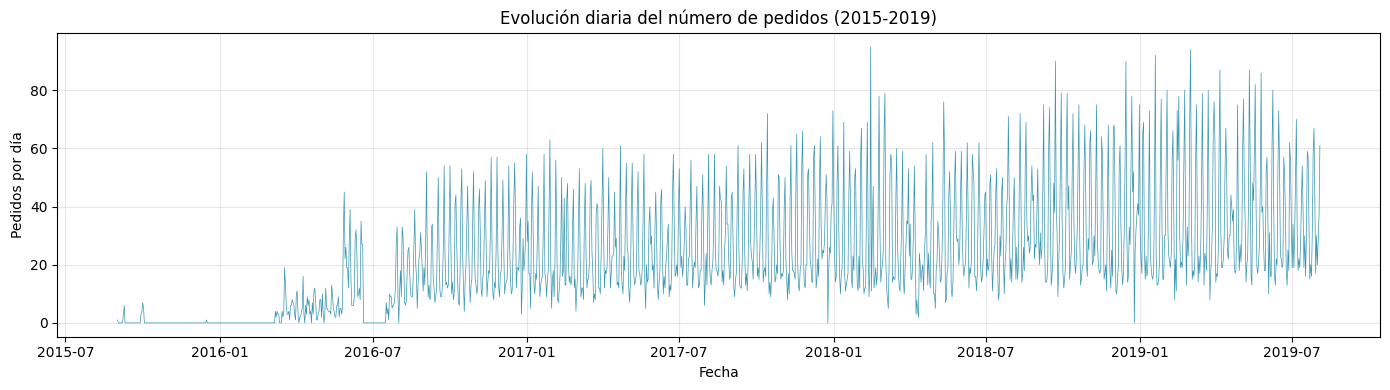

Resumen por año:
      dias_con_pedidos  dias_totales  pedidos_totales  pedidos_medios  \
año                                                                     
2015                 8           122               30             0.2   
2016               265           366             4408            12.0   
2017               364           365             9530            26.1   
2018               364           365            11401            31.2   
2019               215           215             7686            35.7   

      cobertura_%  
año                
2015          6.6  
2016         72.4  
2017         99.7  
2018         99.7  
2019        100.0  


In [20]:
import matplotlib.pyplot as plt

# Reconstruimos el rango temporal completo rellenando huecos con 0
serie_completa = (
    serie_diaria
    .set_index("fecha")
    .reindex(rango_completo, fill_value=0)
    .rename_axis("fecha")
    .reset_index()
)

# Gráfico de la serie completa
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie_completa["fecha"], serie_completa["n_pedidos"], linewidth=0.5, color="#3896b0")
ax.set_title("Evolución diaria del número de pedidos (2015-2019)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen por año para identificar el régimen de operación
serie_completa["año"] = serie_completa["fecha"].dt.year
resumen_anual = serie_completa.groupby("año").agg(
    dias_con_pedidos=("n_pedidos", lambda x: (x > 0).sum()),
    dias_totales=("n_pedidos", "count"),
    pedidos_totales=("n_pedidos", "sum"),
    pedidos_medios=("n_pedidos", "mean"),
).round(1)
resumen_anual["cobertura_%"] = (resumen_anual["dias_con_pedidos"] / resumen_anual["dias_totales"] * 100).round(1)

print("Resumen por año:")
print(resumen_anual)

## 8. Selección de la ventana de entrenamiento

El análisis visual y el resumen anual muestran una clara fase de arranque
del negocio entre septiembre de 2015 y el verano de 2016. Durante este
periodo la cobertura de datos es muy baja (6,6% en 2015 y 72,4% en 2016)
y el volumen medio de pedidos es reducido y muy volátil, lo que no
representa la operativa normal del restaurante. 

A partir de 2017 la proporción de días con pedidos se estabiliza en el 99,7% 
y el volumen medio de pedidos crece de forma sostenida (26 pedidos/día en 2017,
31 en 2018, 36 en 2019), lo que confirma que el negocio ha alcanzado su
funcionamiento habitual.

Se establece como fecha de inicio del periodo de entrenamiento el 1 de
septiembre de 2016. Esta decisión descarta la fase de arranque y asegura
que el modelo se entrene sobre datos representativos del funcionamiento
habitual del restaurante. La ventana utilizada abarca 35 meses
(del 1 de septiembre de 2016 al 3 de agosto de 2019), 
suficiente para capturar patrones estacionales anuales completos y
realizar validación cruzada en condiciones.

In [21]:
# Fecha de corte basada en el análisis exploratorio
FECHA_INICIO = pd.Timestamp("2016-09-01")

# Aplicamos el filtro temporal sobre la serie completa
serie_modelado = serie_completa[serie_completa["fecha"] >= FECHA_INICIO].copy()
serie_modelado = serie_modelado.drop(columns=["año"]).reset_index(drop=True)

# Verificamos la serie resultante
print(f"Ventana de entrenamiento: {serie_modelado['fecha'].min().date()} → {serie_modelado['fecha'].max().date()}")
print(f"Días totales:             {len(serie_modelado):,}")
print(f"Días sin pedidos:         {(serie_modelado['n_pedidos'] == 0).sum()}")
print(f"Pedidos totales:          {serie_modelado['n_pedidos'].sum():,}")
print(f"\nEstadísticas de pedidos por día:")
print(serie_modelado["n_pedidos"].describe().round(1))

Ventana de entrenamiento: 2016-09-01 → 2019-08-03
Días totales:             1,067
Días sin pedidos:         2
Pedidos totales:          31,432

Estadísticas de pedidos por día:
count    1067.0
mean       29.5
std        18.2
min         0.0
25%        16.0
50%        23.0
75%        40.0
max        95.0
Name: n_pedidos, dtype: float64


## 9. Persistencia del dataset procesado

Una vez construida la serie de trabajo, se guardan dos ficheros en
`data/processed/`:

- `serie_diaria_pedidos.csv`: la serie temporal agregada a nivel diario,
  que constituye la variable objetivo de los modelos predictivos.
- `pedidos_unicos.csv`: los pedidos individuales con su fecha y hora,
  que se utilizarán en los siguientes notebooks para análisis de
  granularidad fina (perfil horario, franjas de servicio).

Se utiliza el formato CSV por su simplicidad y compatibilidad.

In [23]:
from pathlib import Path

DATA_PROCESSED = Path("../data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

ruta_salida = DATA_PROCESSED / "serie_diaria_pedidos.csv"
serie_modelado.to_csv(ruta_salida, index=False)

print(f"Serie guardada en: {ruta_salida}")
print(f"Tamaño: {ruta_salida.stat().st_size / 1024:.1f} KB")

# Guardamos también los pedidos únicos para análisis granulares posteriores
ruta_pedidos = DATA_PROCESSED / "pedidos_unicos.csv"
pedidos_unicos.to_csv(ruta_pedidos, index=False)
print(f"Pedidos únicos guardados en: {ruta_pedidos}")
print(f"Tamaño: {ruta_pedidos.stat().st_size / 1024:.1f} KB")

Serie guardada en: ..\data\processed\serie_diaria_pedidos.csv
Tamaño: 15.6 KB
Pedidos únicos guardados en: ..\data\processed\pedidos_unicos.csv
Tamaño: 1418.7 KB


## 10. Resumen y próximos pasos

Al finalizar este notebook se ha obtenido una serie temporal diaria
del número de pedidos, limpia y lista para el entrenamiento de los
modelos predictivos. Las transformaciones aplicadas han sido:

- Carga y unificación de los pedidos de los dos restaurantes del dataset.
- Parseo explícito de las fechas en formato DD/MM/YYYY.
- Agregación de las líneas de producto a nivel de pedido único,
  confirmando los 33.055 pedidos documentados en el análisis exploratorio.
- Construcción de la serie diaria agregada para ambos restaurantes.
- Descarte de la fase de arranque del negocio, estableciendo como
  ventana de entrenamiento el periodo del 1 de septiembre de 2016 al
  3 de agosto de 2019 (1.067 días, 31.432 pedidos).

La serie se ha guardado en `data/processed/serie_diaria_pedidos.csv`.
El siguiente notebook (`02_enriquecimiento_datos.ipynb`) incorporará
las variables contextuales (meteorología mediante la API Open-Meteo y
festivos del Reino Unido mediante la librería `holidays`) que
constituyen la aportación diferencial del modelo principal frente al
modelo de referencia.